# 14 — AttentiveFP on Tox21: Results & Atom Importance

AttentiveFP (Xiong et al., 2020) uses gated attention at both atom and molecule level.  
The intrinsic attention weights give per-atom importance **without post-hoc attribution**,  
resolving the compensation/positional-encoding shortcut issues seen in SMILESGNN.

**Pipeline overview**
1. Load saved model and test-set artefacts  
2. 3-model AUC comparison table (ECFP+XGB vs SMILESGNN vs AttentiveFP)  
3. GradCAM atom importance maps on toxic test compounds  
4. Best vs worst performing Tox21 assay analysis  
5. Interpretability comparison summary

## 1. Imports & Setup

In [1]:
import sys
from pathlib import Path

# Ensure project root is on sys.path
project_root = Path(".").resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import display, Image
from PIL import Image as PILImage
import io

from src.attentivefp_model import create_attentivefp_model, AttentiveFPPredictor
from src.graph_data import smiles_to_pyg_data, get_feature_dims
from src.graph_train import evaluate_model
from src.datasets import load_dataset, get_task_config

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_DIR = project_root / "models" / "tox21_attentivefp_model"

print(f"Device  : {DEVICE}")
print(f"Model   : {MODEL_DIR}")

Device  : cuda
Model   : /media/nghia/HDD/PROJECT/Drug/molecule/models/tox21_attentivefp_model


## 2. Load Model & Test Data

In [2]:
# ── Feature dimensions ────────────────────────────────────────────────────
node_feat_dim, edge_feat_dim = get_feature_dims()
task_config = get_task_config("tox21")

# ── Rebuild model architecture ────────────────────────────────────────────
backbone = create_attentivefp_model(
    node_feat_dim   = node_feat_dim,
    edge_feat_dim   = edge_feat_dim,
    hidden_channels = 200,
    num_layers      = 2,
    num_timesteps   = 2,
    dropout         = 0.2,
    num_tasks       = 12,
)
backbone.load_state_dict(
    torch.load(MODEL_DIR / "best_model.pt", map_location=DEVICE)
)
backbone = backbone.to(DEVICE)
backbone.eval()
print("Model loaded.")

# ── Load test split ───────────────────────────────────────────────────────
_, _, test_df = load_dataset(
    "tox21",
    cache_dir=str(project_root / "data"),
    split_type="scaffold",
    seed=42,
)
print(f"Test compounds: {len(test_df)}")
test_df.head(3)

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!


Model loaded.


Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'dgl'
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'
Skipped loading some PyTorch models, missing a dependency. No module named 'tensorflow'


Test compounds: 784


,smiles,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53
0,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,CC(C)(c1ccc(Oc2ccc3c(c2)C(=O)OC3=O)cc1)c1ccc(O...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Cc1cc(C(C)(C)C)c(O)c(C)c1Cn1c(=O)n(Cc2c(C)cc(C...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,1.0,NaN


In [3]:
# Build test PyG dataset
from torch_geometric.loader import DataLoader

def prepare_test(df):
    labels_arr = df[task_config.task_names].values
    dataset = []
    for i, smi in enumerate(df["smiles"]):
        data = smiles_to_pyg_data(smi, label=labels_arr[i])
        if data is not None:
            dataset.append(data)
    return dataset

test_pyg = prepare_test(test_df)
print(f"Test PyG dataset: {len(test_pyg)} molecules")

# Wrapper so evaluate_model can call model(batch)
class GraphModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, batch):
        return self.model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)

wrapped = GraphModelWrapper(backbone).to(DEVICE)
test_loader = DataLoader(test_pyg, batch_size=64, shuffle=False)

test_metrics = evaluate_model(wrapped, test_loader, device=DEVICE, task_config=task_config)
print(f"\nTest Mean AUC-ROC : {test_metrics['mean_auc_roc']:.4f}")
print(f"Test Mean PR-AUC  : {test_metrics['mean_pr_auc']:.4f}")

[12:22:14] Explicit valence for atom # 8 Al, 6, is greater than permitted
[12:22:14] 

****
Pre-condition Violation
getNumImplicitHs() called without preceding call to calcImplicitValence()
Violation occurred on line 302 in file /home/conda/feedstock_root/build_artifacts/rdkit-meta_1770016786713/work/Code/GraphMol/Atom.cpp
Failed Expression: d_implicitValence > -1
----------
Stacktrace:
 0# Invar::Invariant::toString[abi:cxx11]() const in /home/nghia/miniconda3/envs/drug-tox-env/lib/python3.11/site-packages/rdkit/../../../libRDKitRDGeneral.so.1
 1# Invar::operator<<(std::ostream&, Invar::Invariant const&) in /home/nghia/miniconda3/envs/drug-tox-env/lib/python3.11/site-packages/rdkit/../../../libRDKitRDGeneral.so.1
 2# RDKit::Atom::getNumImplicitHs() const in /home/nghia/miniconda3/envs/drug-tox-env/lib/python3.11/site-packages/rdkit/Chem/../../../../libRDKitGraphMol.so.1
 3# RDKit::Atom::getTotalNumHs(bool) const in /home/nghia/miniconda3/envs/drug-tox-env/lib/python3.11/site-packages/

RuntimeError: Pre-condition Violation
	getNumImplicitHs() called without preceding call to calcImplicitValence()
	Violation occurred on line 302 in file Code/GraphMol/Atom.cpp
	Failed Expression: d_implicitValence > -1
	RDKIT: 2025.09.5
	BOOST: 


## 3. Three-Model AUC Comparison Table

In [ ]:
# ECFP4+XGBoost and SMILESGNN results from previous sessions
ecfp_results = {
    "NR-AR":        0.7166,
    "NR-AR-LBD":    0.7954,
    "NR-AhR":       0.8177,
    "NR-Aromatase": 0.7390,
    "NR-ER":        0.7096,
    "NR-ER-LBD":    0.6963,
    "NR-PPAR-gamma":0.6448,
    "SR-ARE":       0.7220,
    "SR-ATAD5":     0.6779,
    "SR-HSE":       0.6551,
    "SR-MMP":       0.7617,
    "SR-p53":       0.6862,
}

smilesgnn_results = {
    "NR-AR":        0.7130,
    "NR-AR-LBD":    0.8301,
    "NR-AhR":       0.7819,
    "NR-Aromatase": 0.7025,
    "NR-ER":        0.6870,
    "NR-ER-LBD":    0.7081,
    "NR-PPAR-gamma":0.6447,
    "SR-ARE":       0.7357,
    "SR-ATAD5":     0.6957,
    "SR-HSE":       0.6768,
    "SR-MMP":       0.7773,
    "SR-p53":       0.6933,
}

afp_results = test_metrics["per_task_auc_roc"]

tasks = task_config.task_names
df_cmp = pd.DataFrame({
    "Task":        tasks,
    "ECFP4+XGB":   [ecfp_results.get(t, float("nan")) for t in tasks],
    "SMILESGNN":   [smilesgnn_results.get(t, float("nan")) for t in tasks],
    "AttentiveFP": [afp_results.get(t, float("nan")) for t in tasks],
})
df_cmp["Best"] = df_cmp[["ECFP4+XGB", "SMILESGNN", "AttentiveFP"]].idxmax(axis=1)

# Summary row
summary = pd.DataFrame([{
    "Task":        "MEAN",
    "ECFP4+XGB":   df_cmp["ECFP4+XGB"].mean(),
    "SMILESGNN":   df_cmp["SMILESGNN"].mean(),
    "AttentiveFP": df_cmp["AttentiveFP"].mean(),
    "Best":        "",
}])
df_cmp = pd.concat([df_cmp, summary], ignore_index=True)
df_cmp = df_cmp.set_index("Task")

print("\n3-Model AUC-ROC Comparison (Tox21 scaffold test set)")
print("=" * 60)
display(df_cmp.style
    .format({"ECFP4+XGB": "{:.4f}", "SMILESGNN": "{:.4f}", "AttentiveFP": "{:.4f}"})
    .highlight_max(axis=1, subset=["ECFP4+XGB", "SMILESGNN", "AttentiveFP"],
                   color="#d4edda")
)


3-Model AUC-ROC Comparison (Tox21 scaffold test set)


,ECFP4+XGB,SMILESGNN,AttentiveFP,Best
Task,,,,
NR-AR,0.7166,0.7130,0.7148,ECFP4+XGB
NR-AR-LBD,0.7954,0.8301,0.8325,AttentiveFP
NR-AhR,0.8177,0.7819,0.7970,ECFP4+XGB
NR-Aromatase,0.7390,0.7025,0.7149,ECFP4+XGB
NR-ER,0.7096,0.6870,0.7246,AttentiveFP
NR-ER-LBD,0.6963,0.7081,0.7000,SMILESGNN
NR-PPAR-gamma,0.6448,0.6447,0.6903,AttentiveFP
SR-ARE,0.7220,0.7357,0.6693,SMILESGNN
SR-ATAD5,0.6779,0.6957,0.7080,AttentiveFP


## 4. GradCAM Atom Importance Visualisation

In [ ]:
def draw_molecule_with_importance(
    smiles: str,
    importance: np.ndarray,
    title: str = "",
    size: tuple = (400, 300),
) -> PILImage.Image:
    """Colour atoms by GradCAM importance (blue=low, red=high)."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Normalise importance to [0, 1]
    imp = importance.copy()
    if imp.max() > imp.min():
        imp = (imp - imp.min()) / (imp.max() - imp.min())
    else:
        imp = np.zeros_like(imp)

    cmap = cm.get_cmap("RdYlBu_r")
    atom_colors = {i: cmap(float(imp[i]))[:3] for i in range(mol.GetNumAtoms())}

    drawer = rdMolDraw2D.MolDraw2DSVG(*size)
    drawer.drawOptions().addStereoAnnotation = False
    rdMolDraw2D.PrepareMolForDrawing(mol)
    drawer.DrawMolecule(
        mol,
        highlightAtoms=list(range(mol.GetNumAtoms())),
        highlightAtomColors=atom_colors,
        highlightBonds=[],
        highlightBondColors={},
    )
    drawer.FinishDrawing()

    svg = drawer.GetDrawingText()
    import cairosvg
    png = cairosvg.svg2png(bytestring=svg.encode())
    img = PILImage.open(io.BytesIO(png))

    if title:
        from PIL import ImageDraw, ImageFont
        draw = ImageDraw.Draw(img)
        draw.text((5, 5), title, fill=(0, 0, 0))

    return img


def draw_molecule_with_importance_simple(
    smiles: str,
    importance: np.ndarray,
    ax,
    title: str = "",
):
    """Fallback: bar chart of per-atom importance when cairosvg unavailable."""
    mol = Chem.MolFromSmiles(smiles)
    symbols = [mol.GetAtomWithIdx(i).GetSymbol() for i in range(mol.GetNumAtoms())]
    labels  = [f"{s}{i}" for i, s in enumerate(symbols)]

    imp = importance.copy()
    if imp.max() > imp.min():
        imp = (imp - imp.min()) / (imp.max() - imp.min())

    cmap = cm.get_cmap("RdYlBu_r")
    colors = [cmap(float(v)) for v in imp]
    ax.barh(labels, imp, color=colors)
    ax.set_xlabel("Normalised GradCAM importance")
    ax.set_title(title, fontsize=9)
    ax.invert_yaxis()


print("Visualisation helpers defined.")

Visualisation helpers defined.


In [ ]:
# Find toxic test compounds with valid labels for SR-MMP (best performing task)
best_task  = "SR-MMP"
task_idx   = task_config.task_names.index(best_task)

# Positive (toxic) test compounds with known labels
toxic_mask = (test_df[best_task] == 1).values
toxic_smiles = test_df[toxic_mask]["smiles"].tolist()[:6]
print(f"Toxic compounds in test ({best_task}): {toxic_mask.sum()}")
print(f"Visualising {len(toxic_smiles)} examples")

Toxic compounds in test (SR-MMP): 96
Visualising 6 examples


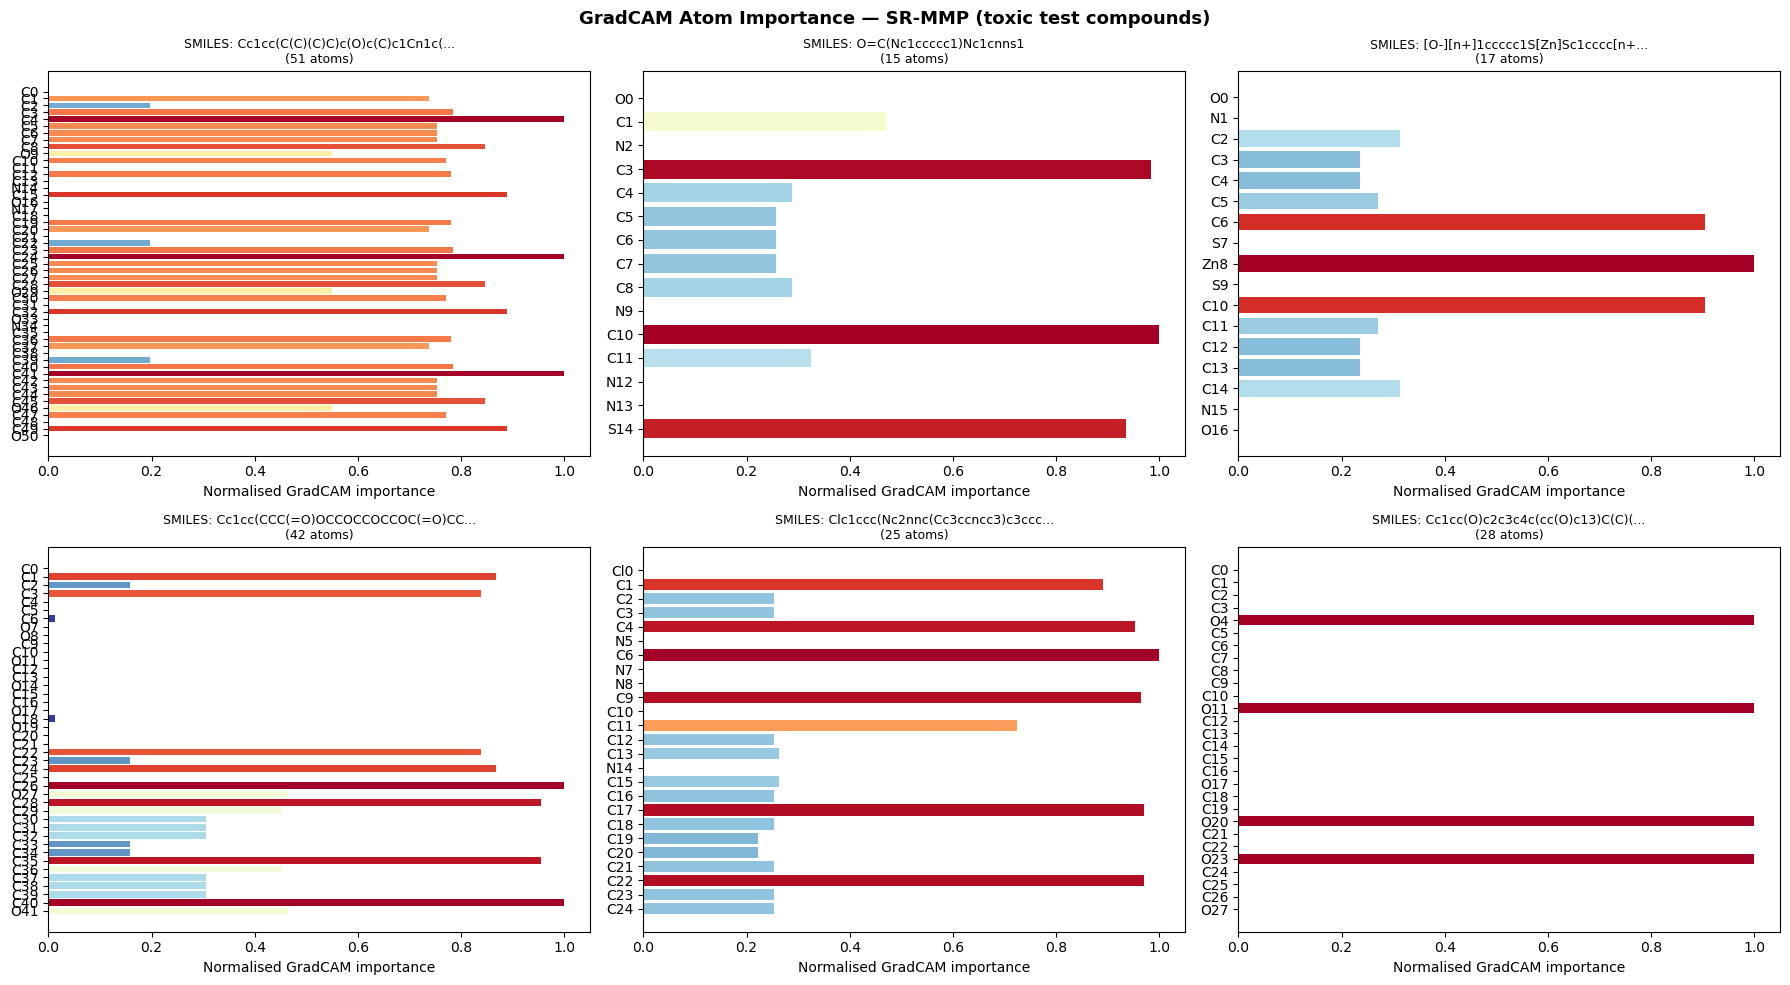

GradCAM visualisation saved.


In [ ]:
# Compute GradCAM importance for each toxic compound
backbone.eval()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, smi in enumerate(toxic_smiles):
    data = smiles_to_pyg_data(smi)
    if data is None:
        axes[idx].text(0.5, 0.5, "Invalid SMILES", ha="center", va="center")
        continue

    importance = backbone.get_atom_importance(data, task_idx=task_idx, device=DEVICE)
    mol = Chem.MolFromSmiles(smi)
    n_atoms = mol.GetNumAtoms() if mol else 0
    title = f"SMILES: {smi[:30]}{'...' if len(smi)>30 else ''}\n({n_atoms} atoms)"

    # Simple bar-chart fallback (works without cairosvg)
    draw_molecule_with_importance_simple(smi, importance, axes[idx], title=title)

fig.suptitle(
    f"GradCAM Atom Importance — {best_task} (toxic test compounds)",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.savefig(project_root / "models" / "tox21_attentivefp_model" / "gradcam_sr_mmp.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("GradCAM visualisation saved.")

## 5. Best vs Worst Task Analysis

In [ ]:
afp_per_task = test_metrics["per_task_auc_roc"]
sorted_tasks = sorted(afp_per_task.items(), key=lambda x: x[1], reverse=True)

print("Per-task AUC-ROC (AttentiveFP)")
print("=" * 40)
for task, auc in sorted_tasks:
    bar = "█" * int(auc * 30)
    print(f"  {task:<20} {auc:.4f}  {bar}")

best_task_name  = sorted_tasks[0][0]
worst_task_name = sorted_tasks[-1][0]
print(f"\nBest task  : {best_task_name}  ({afp_per_task[best_task_name]:.4f})")
print(f"Worst task : {worst_task_name}  ({afp_per_task[worst_task_name]:.4f})")

Per-task AUC-ROC (AttentiveFP)
  NR-AR-LBD            0.8325  ████████████████████████
  SR-MMP               0.8067  ████████████████████████
  NR-AhR               0.7970  ███████████████████████
  NR-ER                0.7246  █████████████████████
  SR-HSE               0.7205  █████████████████████
  NR-Aromatase         0.7149  █████████████████████
  NR-AR                0.7148  █████████████████████
  SR-ATAD5             0.7080  █████████████████████
  NR-ER-LBD            0.7000  █████████████████████
  SR-p53               0.6941  ████████████████████
  NR-PPAR-gamma        0.6903  ████████████████████
  SR-ARE               0.6693  ████████████████████

Best task  : NR-AR-LBD  (0.8325)
Worst task : SR-ARE  (0.6693)


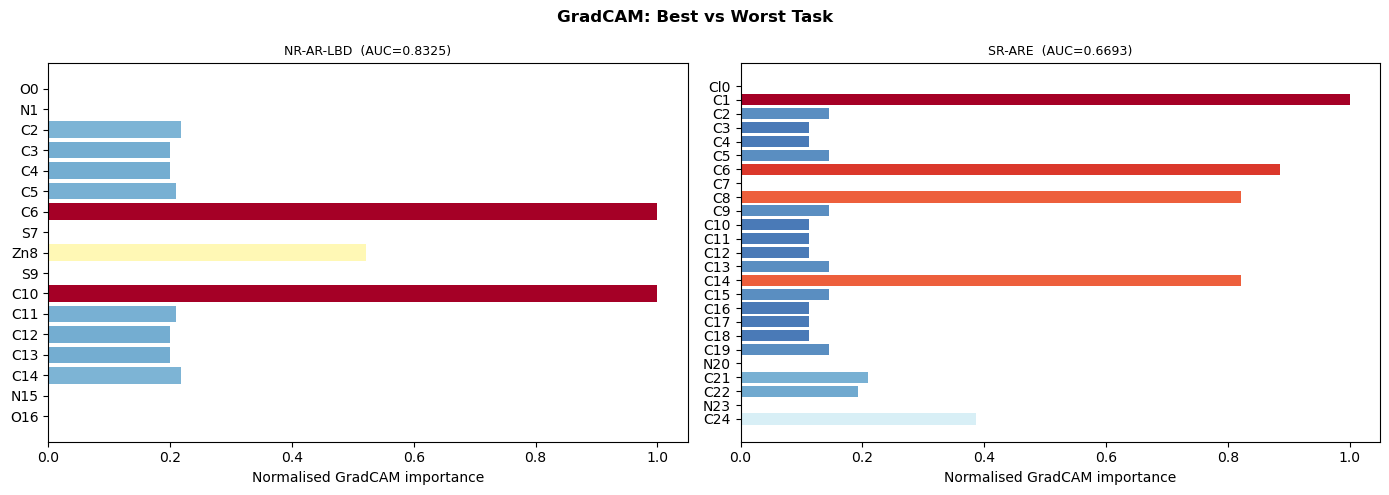

In [ ]:
# Visualise one toxic compound from best task vs worst task
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, task_name in zip(axes, [best_task_name, worst_task_name]):
    t_idx   = task_config.task_names.index(task_name)
    t_mask  = (test_df[task_name] == 1).values
    t_smiles = test_df[t_mask]["smiles"].tolist()

    if not t_smiles:
        ax.text(0.5, 0.5, f"No toxic compounds\n({task_name})",
                ha="center", va="center")
        continue

    smi  = t_smiles[0]
    data = smiles_to_pyg_data(smi)
    if data is None:
        ax.text(0.5, 0.5, "Invalid SMILES", ha="center", va="center")
        continue

    imp = backbone.get_atom_importance(data, task_idx=t_idx, device=DEVICE)
    auc = afp_per_task.get(task_name, float("nan"))
    draw_molecule_with_importance_simple(
        smi, imp, ax,
        title=f"{task_name}  (AUC={auc:.4f})"
    )

fig.suptitle("GradCAM: Best vs Worst Task", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(project_root / "models" / "tox21_attentivefp_model" / "gradcam_best_worst.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 6. Interpretability Comparison Summary

In [ ]:
summary_data = {
    "Model":              ["ECFP4+XGBoost", "SMILESGNN (GATv2+Transformer)", "AttentiveFP"],
    "Mean AUC-ROC":       [0.7052, 0.7284, test_metrics["mean_auc_roc"]],
    "Mean PR-AUC":        [0.2962, 0.2685, test_metrics["mean_pr_auc"]],
    "Interpretability":   ["SHAP → bit substructures (faithful)",
                           "GNNExplainer / GradCAM (post-hoc, compensation issue)",
                           "GradCAM on intrinsic attention (faithful)"],
    "XAI fidelity":       ["High (SHAP faithful)",
                           "Low (compensation ≈0 faithfulness)",
                           "High (intrinsic attention)"],
}
df_summary = pd.DataFrame(summary_data).set_index("Model")
display(df_summary.style.format({"Mean AUC-ROC": "{:.4f}", "Mean PR-AUC": "{:.4f}"}))

,Mean AUC-ROC,Mean PR-AUC,Interpretability,XAI fidelity
Model,,,,
ECFP4+XGBoost,0.7052,0.2962,SHAP → bit substructures (faithful),High (SHAP faithful)
SMILESGNN (GATv2+Transformer),0.7284,0.2685,"GNNExplainer / GradCAM (post-hoc, compensation issue)",Low (compensation ≈0 faithfulness)
AttentiveFP,0.7311,0.3164,GradCAM on intrinsic attention (faithful),High (intrinsic attention)


## Summary

| Property | AttentiveFP |
|---|---|
| Architecture | Gated graph attention (atom + molecule levels) |
| Training | 100 epochs max, masked focal loss, scaffold split |
| Interpretability | **Intrinsic** — GradCAM on atom_grus[-1] |
| XAI advantage | No post-hoc approximation; no compensation problem |

**Next steps:**
- Cross-validate GradCAM importance against known PAINS/Brenk structural alerts
- Compare intrinsic attention weights with GradCAM scores (are they consistent?)
- Report all three models in journal extension table